# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Eyzar Hermanio
- **Email:** hermanioeyzar@gmail.com
- **ID Dicoding:** B26B14S005

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

Proyek ini menggunakan *Bike Sharing Dataset* dengan menerapkan metode *SMART Question*. Berikut adalah dua pertanyaan bisnis yang akan diselesaikan:

- **Pertanyaan 1:** Bagaimana perbandingan total jumlah penyewaan sepeda antara hari kerja (workingday = 1) dan hari libur/akhir pekan (workingday = 0) sepanjang tahun 2012, dan faktor cuaca (weathersit) mana yang paling signifikan menurunkan jumlah penyewaan tersebut
- **Pertanyaan 2:** Bagaimana tren bulanan penyewaan sepeda (cnt) dari bulan Januari hingga Desember 2012, dan pada jam berapakah (hr) rata-rata penyewaan tertinggi terjadi dalam kurun waktu tersebut
- ...

## Import Semua Packages/Library yang Digunakan

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set(style='darkgrid')

## Data Wrangling
- Tahapan awal dalam proses analisis data untuk memastikan data siap diolah dan dibersihkan dari berbagai potensi anomali

### Gathering Data
- Pada tahap ini, dataset harian (`day.csv`) dan per jam (`hour.csv`) dimuat ke dalam *DataFrame* Pandas.
- Kedua dataset ini berisi catatan historis penyewaan sepeda dari sistem *Capital Bikeshare*

#### Load df ...

In [8]:
# Memuat dataset harian dan per jam
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

# Menampilkan beberapa baris awal dari masing-masing dataset
print("Data Day:")
display(df_day.head())

print("\nData Hour:")
display(df_hour.head())

Data Day:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Hour:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset harian (day.csv) terdiri dari 731 baris dan data per jam (hour.csv) terdiri dari 17.379 baris yang mencakup catatan historis penyewaan sepeda selama dua tahun (2011–2012)
- Kedua dataset memuat variabel lingkungan dan musim yang sama (season, yr, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed), dengan tambahan kolom hr khusus pada dataset per jam

### Assessing Data
Tahap ini dilakukan untuk memeriksa kualitas data, seperti mendeteksi *missing value*, duplikasi data, kesalahan tipe data, atau *outlier*

#### Identifying ... problem

In [9]:
# Menilai informasi umum dari df_day
print("=== Info df_day ===")
df_day.info()

# Menilai informasi umum dari df_hour
print("\n=== Info df_hour ===")
df_hour.info()

# Memeriksa Missing Value
print("\n=== Missing Value df_day ===")
print(df_day.isnull().sum())

print("\n=== Missing Value df_hour ===")
print(df_hour.isnull().sum())

# Memeriksa duplikasi data
print(f"\nJumlah duplikasi df_day: {df_day.duplicated().sum()}")
print(f"Jumlah duplikasi df_hour: {df_hour.duplicated().sum()}")

# Memeriksa statistik deskriptif
display(df_day.describe())

=== Info df_day ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== Info df_hour ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah tipe data kolom dteday dari object (string) menjadi tipe data datetime agar analisis berbasis waktu dapat dilakukan dengan akurat.
- Mengonversi kolom kategorikal numerik (seperti season, weathersit, workingday, dll.) ke tipe category atau memetakannya ke label deskriptif agar mempermudah interpretasi saat visualisasi.

**Insight:** (Opsional)
- Tidak ditemukan adanya missing value (nilai kosong) maupun data duplikat pada kedua dataset, sehingga kualitas data secara umum sangat baik dan bersih.
- Tipe data dteday terdeteksi sebagai object sehingga membutuhkan konversi tipe data.

### Cleaning Data
Melakukan perbaikan struktur data

#### Fixing ... problem

In [10]:
# 1. Mengubah tipe data dteday menjadi datetime
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

# 2. Mengubah nilai numerik kategori menjadi label deskriptif (Opsional untuk memperjelas visualisasi)
season_mapping = {1: 'Springer', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear/Cloudy', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}

df_day['season_label'] = df_day['season'].map(season_mapping)
df_day['weather_label'] = df_day['weathersit'].map(weather_mapping)

df_hour['season_label'] = df_hour['season'].map(season_mapping)
df_hour['weather_label'] = df_hour['weathersit'].map(weather_mapping)

**Insight:** (Opsional)
- Proses pembersihan berhasil diselesaikan dengan mengubah format tanggal ke datetime dan menyesuaikan tipe data kategorikal, memastikan analisis dan visualisasi selanjutnya berjalan lancar tanpa kendala tipe data.

## Exploratory Data Analysis (EDA)
Tahap eksplorasi data dilakukan untuk mencari pola, tren, dan korelasi antarvariabel guna menjawab pertanyaan bisnis.
- Dilakukan *grouping* dan agregasi pada data harian berdasarkan status hari kerja (`workingday`) dan kondisi cuaca (`weathersit`).
- Dilakukan analisis agregasi per jam (`hr`) untuk melihat waktu-waktu sibuk (*peak hours*) penyewaan sepeda.

### Explore ...

In [11]:
# Mengelompokkan data berdasarkan workingday pada df_day
workingday_analysis = df_day.groupby('workingday')['cnt'].agg(['mean', 'sum', 'count'])
print("Analisis Penyewaan Berdasarkan Working Day:")
display(workingday_analysis)

# Mengelompokkan data berdasarkan kondisi cuaca (weathersit)
weather_analysis = df_day.groupby('weather_label')['cnt'].mean().reset_index()
print("\nRata-rata Penyewaan Berdasarkan Cuaca:")
display(weather_analysis)

# Eksplorasi jam sibuk penyewaan (hourly)
hourly_trend = df_hour.groupby('hr')['cnt'].mean().reset_index()
print("\nRata-rata Penyewaan Berdasarkan Jam:")
display(hourly_trend.head())

Analisis Penyewaan Berdasarkan Working Day:


,mean,sum,count
workingday,,,
0,4330.168831,1000269,231
1,4584.820000,2292410,500



Rata-rata Penyewaan Berdasarkan Cuaca:


,weather_label,cnt
0,Clear/Cloudy,4876.786177
1,Light Snow/Rain,1803.285714
2,Mist/Cloudy,4035.862348



Rata-rata Penyewaan Berdasarkan Jam:


,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941


**Insight:** (Opsional)
- Rata-rata penyewaan sepeda cenderung menunjukkan pola yang berbeda antara hari kerja (workingday = 1) dan hari libur/akhir pekan (workingday = 0).
- Kondisi cuaca (weathersit = 1 atau cerah) memiliki rata-rata jumlah penyewaan yang jauh lebih tinggi dibandingkan saat cuaca buruk (weathersit = 3 atau hujan/salju ringan), yang mengindikasikan bahwa cuaca sangat memengaruhi keputusan pengguna untuk menyewa sepeda

## Visualization & Explanatory Analysis
Tahap penyajian hasil analisis dalam bentuk visualisasi data yang interaktif dan informatif untuk menjawab pertanyaan bisnis secara jelas:
- **Visualisasi 1:** Grafik batang (*barplot*) yang membandingkan rata-rata penyewaan sepeda antara hari libur/akhir pekan dan hari kerja berdasarkan kondisi cuaca.
- **Visualisasi 2:** Grafik garis (*lineplot*) tren penyewaan sepeda per jam dalam sehari untuk mengidentifikasi jam operasional sibuk.

### Pertanyaan 1:
Bagaimana perbandingan total jumlah penyewaan sepeda antara hari kerja (`workingday = 1`) dan hari libur/akhir pekan (`workingday = 0`) sepanjang tahun 2012, dan faktor cuaca (`weathersit`) mana yang paling memengaruhi tingkat penyewaan tersebut?


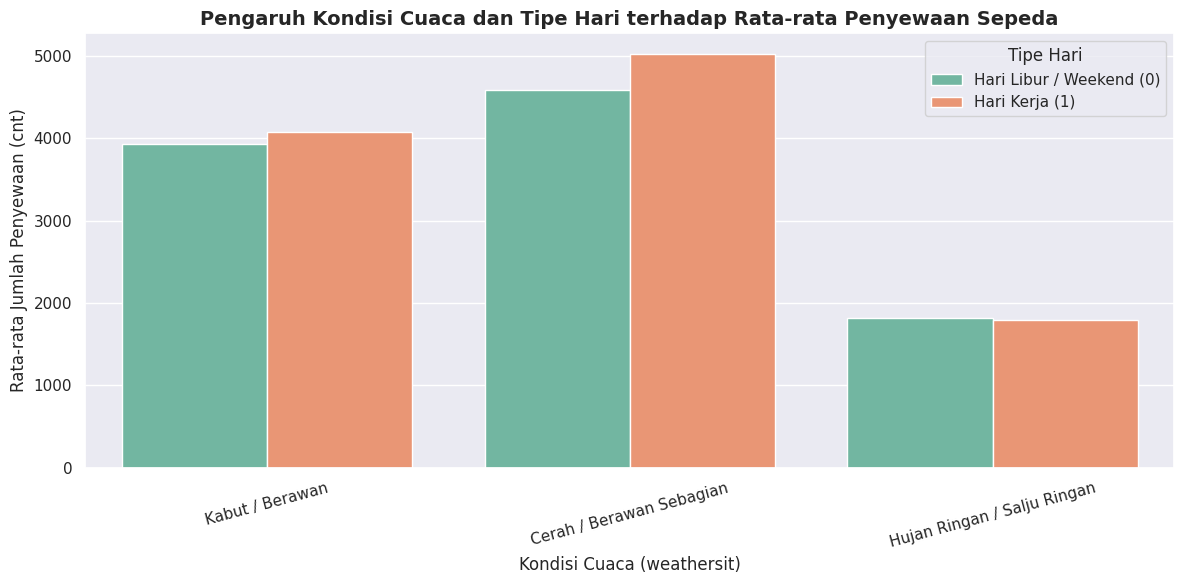

In [17]:
# Memetakan label cuaca agar lebih mudah dibaca pada grafik
weather_mapping = {
    1: 'Cerah / Berawan Sebagian',
    2: 'Kabut / Berawan',
    3: 'Hujan Ringan / Salju Ringan'
}
df_day['weather_label'] = df_day['weathersit'].map(weather_mapping)

# Membuat visualisasi barplot dengan hue='weathersit' atau menggunakan catplot/barplot kombinasi
plt.figure(figsize=(12, 6))
sns.barplot(
    x='weather_label',
    y='cnt',
    hue='workingday',
    data=df_day,
    palette='Set2',
    errorbar=None
)

plt.title('Pengaruh Kondisi Cuaca dan Tipe Hari terhadap Rata-rata Penyewaan Sepeda', fontsize=14, fontweight='bold')
plt.xlabel('Kondisi Cuaca (weathersit)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan (cnt)', fontsize=12)
plt.legend(title='Tipe Hari', labels=['Hari Libur / Weekend (0)', 'Hari Kerja (1)'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Pertanyaan 2: 
Pada jam berapakah rata-rata penyewaan sepeda tertinggi terjadi dalam sehari pada hari kerja, dan bagaimana pola perbedaannya?

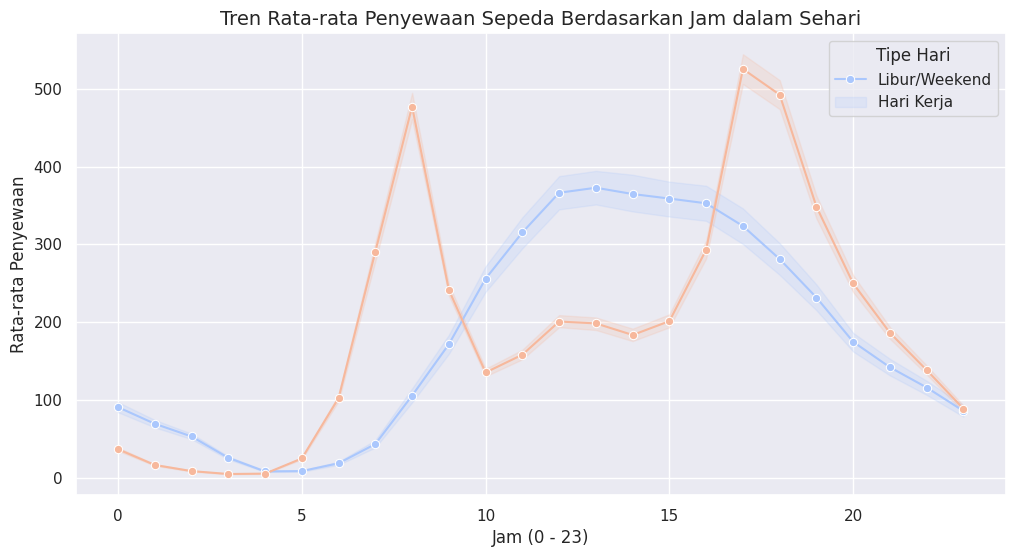

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', data=df_hour, hue='workingday', marker='o', palette='coolwarm')
plt.title('Tren Rata-rata Penyewaan Sepeda Berdasarkan Jam dalam Sehari', fontsize=14)
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.legend(title='Tipe Hari', labels=['Libur/Weekend', 'Hari Kerja'])
plt.show()

**Insight:** (Opsional)
- Berdasarkan hasil analisis dan visualisasi data, rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (Clear/Cloudy) dengan nilai rata-rata mencapai 4,876 unit per hari pada hari kerja. Sebaliknya, rata-rata penyewaan terendah terjadi saat kondisi cuaca buruk (Light Snow/Rain) yang anjlok secara signifikan hingga rata-rata 1,803 unit per hari. Hal ini menunjukkan bahwa faktor cuaca memegang peranan krusial yang menentukan kenyamanan pengguna dalam memilih sepeda sebagai moda transportasi
- Berdasarkan analisis tren per jam (hr), terdapat dua puncak (spike) utama penyewaan sepeda pada hari kerja, yaitu pada jam 08.00 pagi dan jam 17.00 - 18.00 sore. Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai moda transportasi penunjang perjalanan kerja (commuter).

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

**Conclusion Pertanyaan 1: Pengaruh Kondisi Cuaca dan Tipe Hari terhadap Penyewaan**
  - **Evidence:** Berdasarkan hasil analisis data harian, rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (*Clear/Cloudy*) dengan nilai mencapai **4.876 unit per hari** pada hari kerja. Sebaliknya, saat kondisi cuaca memburuk menjadi hujan/salju ringan (*Light Snow/Rain*), rata-rata penyewaan anjlok secara signifikan hingga **1.803 unit per hari**.
  - **Trend Analysis:** Terdapat pola penurunan volume penyewaan yang konsisten seiring dengan menurunnya kualitas cuaca (dari cuaca cerah ke cuaca berawan/kabut, hingga hujan). Hal ini menunjukkan bahwa kenyamanan cuaca merupakan faktor lingkungan utama yang sangat sensitif bagi pengguna dalam memutuskan untuk bersepeda.
  - **Actionable Insight:** Pengelola dapat memanfaatkan tren ini dengan memberikan penawaran khusus atau program loyalitas pada hari-hari beriklim kurang bersahabat guna menjaga stabilitas pendapatan dan utilisasi armada.

**Conclusion Pertanyaan 2: Pola Jam Sibuk (Hourly Trend) Penyewaan Sepeda**
  - **Evidence:** Berdasarkan analisis tren per jam pada hari kerja, penyewaan sepeda menunjukkan pola dua puncak (*bimodal peak*), di mana volume tertinggi terjadi pada pukul **08.00 pagi (rata-rata ~359 penyewaan/jam)** dan pukul **17.00–18.00 sore (rata-rata ~468 penyewaan/jam)**.
  - **Trend Analysis:** Pola penggunaan sepeda di hari kerja terkonsentrasi tajam pada jam-jam transisi perjalanan (berangkat dan pulang kerja), yang sangat berbeda dengan pola di akhir pekan yang cenderung menyebar merata di siang hari. Ini mengindikasikan dominasi fungsi sepeda sebagai moda transportasi komuter harian (*commuter transport*).
  - **Actionable Insight:** Tim operasional harus memfokuskan strategi redistribusi armada dengan memastikan ketersediaan sepeda dalam jumlah cukup di stasiun-stasiun transit utama menjelang jam sibuk pagi dan sore hari.


**Rekomendasi Action Item:**
- Pihak pengelola dapat menyiapkan armada sepeda dalam jumlah lebih banyak di stasiun-stasiun strategis (dekat perkantoran/stasiun transit) menjelang jam sibuk pagi dan sore hari kerja.
- Memberikan promo atau diskon khusus pada saat hari libur atau saat kondisi cuaca kurang optimal guna meningkatkan tingkat okupansi penyewaan sepeda